# **Aluna: Ana Clara Fortunato de Souza**

---

# Classificação dos níveis de líquido da caneca
Este notebook usa transferência de aprendizado com MobileNetV2 para classificar as classes `empty`, `mostly_empty`, `half_full` e `full`.

In [1]:
# No Google Colab, remova o comentário da linha abaixo.
!pip install -q tensorflow seaborn
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


In [3]:
!unzip /content/dataset_caneca.zip -d /content/

Archive:  /content/dataset_caneca.zip
   creating: /content/dataset_caneca/
   creating: /content/dataset_caneca/test/
   creating: /content/dataset_caneca/test/empty/
  inflating: /content/dataset_caneca/test/empty/empty_0000.png  
  inflating: /content/dataset_caneca/test/empty/empty_0001.png  
  inflating: /content/dataset_caneca/test/empty/empty_0002.png  
  inflating: /content/dataset_caneca/test/empty/empty_0003.png  
  inflating: /content/dataset_caneca/test/empty/empty_0004.png  
  inflating: /content/dataset_caneca/test/empty/empty_0005.png  
  inflating: /content/dataset_caneca/test/empty/empty_0006.png  
  inflating: /content/dataset_caneca/test/empty/empty_0007.png  
  inflating: /content/dataset_caneca/test/empty/empty_0008.png  
  inflating: /content/dataset_caneca/test/empty/empty_0009.png  
   creating: /content/dataset_caneca/test/full/
  inflating: /content/dataset_caneca/test/full/full_0000.png  
  inflating: /content/dataset_caneca/test/full/full_0001.png  
  inflat

## 1. Carregamento do dataset

In [4]:
DATASET_DIR = Path('dataset_caneca')
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42
assert DATASET_DIR.exists(), f'Pasta não encontrada: {DATASET_DIR.resolve()}'
train_ds = tf.keras.utils.image_dataset_from_directory(DATASET_DIR / 'train', image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, shuffle=True)
val_ds = tf.keras.utils.image_dataset_from_directory(DATASET_DIR / 'val', image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, shuffle=False)
test_ds = tf.keras.utils.image_dataset_from_directory(DATASET_DIR / 'test', image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, shuffle=False)
class_names = train_ds.class_names
print('Classes:', class_names)

Found 240 files belonging to 4 classes.
Found 60 files belonging to 4 classes.
Found 40 files belonging to 4 classes.
Classes: ['empty', 'full', 'half_full', 'mostly_empty']


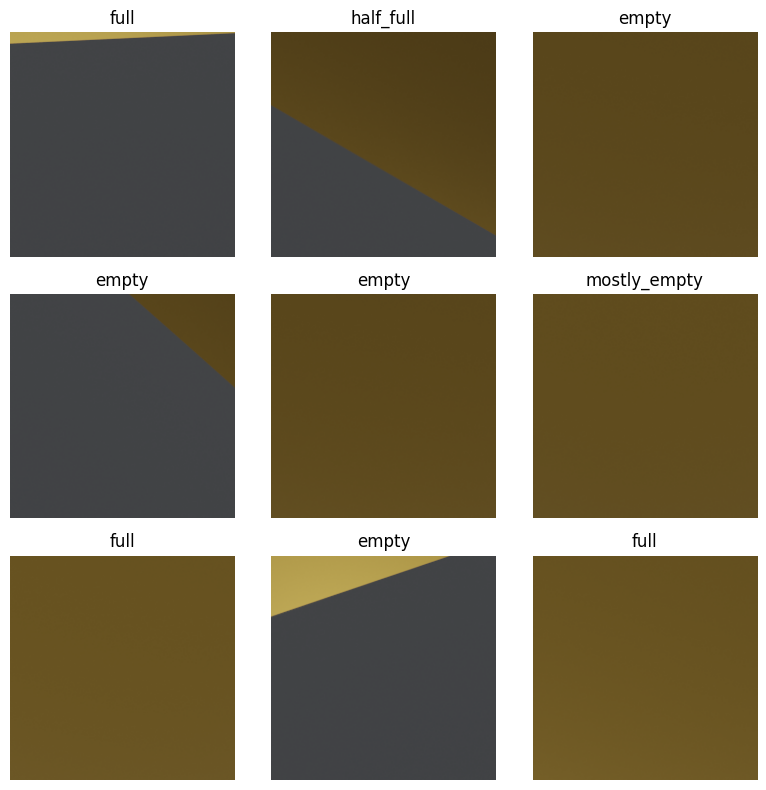

In [5]:
plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[int(labels[i])])
        plt.axis('off')
plt.tight_layout()
plt.savefig('amostras_dataset.png', dpi=180, bbox_inches='tight')
plt.show()

## 2. Modelo por transferência de aprendizado

In [6]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.04),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.RandomContrast(0.08),
])
base = tf.keras.applications.MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
base.trainable = False
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.20)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
callbacks = [tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
history = model.fit(train_ds, validation_data=val_ds, epochs=12, callbacks=callbacks)

## 3. Curvas de treinamento e avaliação

Acurácia no teste: 17.50%


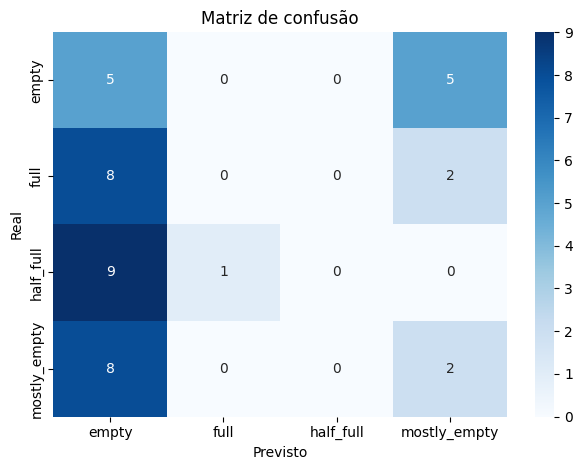

              precision    recall  f1-score   support

       empty       0.17      0.50      0.25        10
        full       0.00      0.00      0.00        10
   half_full       0.00      0.00      0.00        10
mostly_empty       0.22      0.20      0.21        10

    accuracy                           0.17        40
   macro avg       0.10      0.17      0.12        40
weighted avg       0.10      0.17      0.12        40



In [8]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f'Acurácia no teste: {test_acc:.2%}')
y_true = np.concatenate([y.numpy() for _, y in test_ds])
prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(prob, axis=1)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto'); plt.ylabel('Real'); plt.title('Matriz de confusão')
plt.tight_layout(); plt.savefig('matriz_confusao.png', dpi=180, bbox_inches='tight'); plt.show()
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
model.save('classificador_caneca.keras')